In [1]:
from pandas import read_excel
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import soundfile as sf
import functions as fun
from scipy.signal import resample_poly
import json
import gzip

# Annotation
All the annotations are registred in the [annotation_ARPEGE.pkl] file. 

In [2]:
df_annotation = pd.read_pickle("annotation_ARPEGE.pkl")

In [3]:
## You have all the characteristics of every measurement, you can filter from the annotation.
print(df_annotation.columns)

Index(['room', 'pos_num', 'orientation', 'orientation_value', 'type',
       'language', 'speech_part', 'speaker', 'surface_id', 'size_room',
       'src_xyz', 'em32_xyz', 'em64_xyz', 'path', 'mic_id', 'angle_zyz_em32',
       'angle_xyz_src', 'angle_zyz_em64', 'corner_list'],
      dtype='str')


If you want to apply filters on the dataframe, here is an example on the distance source/em32.

In [4]:
## we want the RIRs recorded by mic64 with the source facing the em32
mask = (df_annotation["type"] == 'RIR')  & (df_annotation["mic_id"] == 64) & (df_annotation["orientation"] == 'front') & (df_annotation["orientation_value"] == 32)
## then we filter for the room 1
mask_2 = (df_annotation["room"] == 1)
## here we filter for the RIRs where the distance between the source and the em32 is less than 1.4m
mask_3 = np.zeros(len(df_annotation), dtype=bool)
valid = df_annotation["src_xyz"].notna() & df_annotation["em32_xyz"].notna()
coords_src = np.vstack(df_annotation.loc[valid, "src_xyz"].to_numpy())
coords_em32 = np.vstack(df_annotation.loc[valid, "em32_xyz"].to_numpy())
mask_3[valid] = np.linalg.norm(coords_src - coords_em32, axis=1) < 1.4

df_annotation[mask & mask_2 & mask_3]

,room,pos_num,orientation,orientation_value,type,language,speech_part,speaker,surface_id,size_room,src_xyz,em32_xyz,em64_xyz,path,mic_id,angle_zyz_em32,angle_xyz_src,angle_zyz_em64,corner_list
177,1,1.0,front,32.0,RIR,NaN,NaN,NaN,NaN,"[3.615, 3.84, 2.601]","[0.957, 2.365, 1.591]","[1.249, 1.014, 1.591]","[2.878, 2.749, 1.591]",./ARPEGE_01.2026/room1/pos1/RIR/EM64/room1_pos...,64,"(-177.36736704161746, 25.376626427022565, 125....","(0.0, 0.0, -77.80391143273246)","(-95.97823626692467, 19.664871153896893, -17.1...",[]
185,1,2.0,front,32.0,RIR,NaN,NaN,NaN,NaN,"[3.615, 3.84, 2.601]","[0.957, 2.365, 1.591]","[2.319, 2.383, 1.591]","[2.323, 0.627, 1.591]",./ARPEGE_01.2026/room1/pos2/RIR/EM64/room1_pos...,64,"(-177.36736704161746, 25.376626427022565, 140....","(0.0, 0.0, 0.7571688650585263)","(-95.97823626692467, 19.664871153896893, 104.1...",[]
200,1,5.0,front,32.0,RIR,NaN,NaN,NaN,NaN,"[3.615, 3.84, 2.601]","[1.231, 1.388, 1.591]","[1.885, 2.621, 1.591]","[2.585, 1.664, 1.591]",./ARPEGE_01.2026/room1/pos5/RIR/EM64/room1_pos...,64,"(-177.36736704161746, 25.376626427022565, 92.7...","(0.0, 0.0, 62.05791162914928)","(-95.97823626692467, 19.664871153896893, -177....",[]
202,1,4.0,front,32.0,RIR,NaN,NaN,NaN,NaN,"[3.615, 3.84, 2.601]","[1.231, 1.388, 1.591]","[2.585, 1.664, 1.591]","[1.885, 2.621, 1.591]",./ARPEGE_01.2026/room1/pos4/RIR/EM64/room1_pos...,64,"(-177.36736704161746, 25.376626427022565, 109....","(0.0, 0.0, 11.52135505505952)","(-95.97823626692467, 19.664871153896893, -173....",[]


In [5]:
# this is the path to the RIR
df_annotation[mask & mask_2 & mask_3]["path"].to_list()

['./ARPEGE_01.2026/room1/pos1/RIR/EM64/room1_pos1_front32.wav',
 './ARPEGE_01.2026/room1/pos2/RIR/EM64/room1_pos2_front32.wav',
 './ARPEGE_01.2026/room1/pos5/RIR/EM64/room1_pos5_front32.wav',
 './ARPEGE_01.2026/room1/pos4/RIR/EM64/room1_pos4_front32.wav']

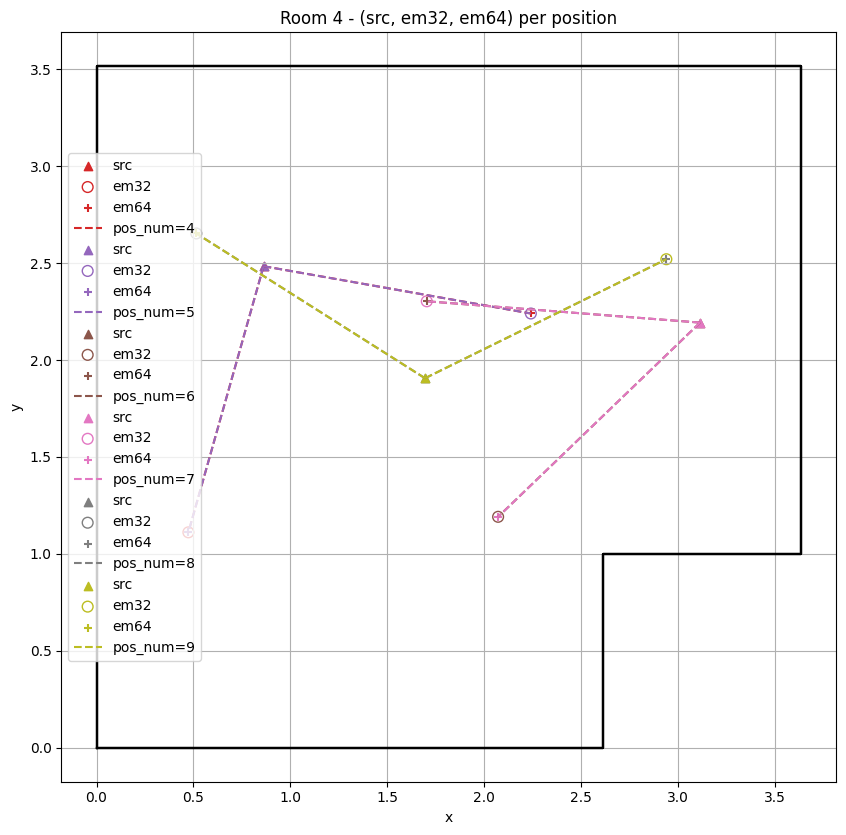

In [7]:
## the first argument is the dataframe, the second is the room number
fun.plot_room(df_annotation, 4)

In [11]:
import pyroomacoustics as pra
from pyroomacoustics.datasets import SOFADatabase , download_sofa_files
import pyroomacoustics.directivities.sofa as sofa
from pyroomacoustics.directivities import (
    MeasuredDirectivityFile,
    Rotation3D,
)
import logging
db = SOFADatabase()

# re-simulate with EM32

In [12]:
path = db['EM32_Directivity'].path
files = sofa.open_sofa_file( path )
pos_eigenmike_32 = files[3]

In [13]:
fs = 16000
src_dir = MeasuredDirectivityFile("LSPs_HATS_GuitarCabinets_Akustikmessplatz", fs=fs,interp_order=18)
genelec8020 = src_dir.get_source_directivity("Genelec_8020", orientation=Rotation3D([ -0, 0], "yz", degrees=True))
eigenmike_32 = MeasuredDirectivityFile("EM32_Directivity", fs=fs, interp_order=18)


here we propose to re-simulate the Room Impulse Responses in the different rooms. 

In [ ]:
# Simulation of a RIR
# Coefficient of absorption more real, per octave band, per walls

abs_coeffs_lower_bound = np.array([[0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.05,0.15,0.25,0.30],
    [0.01,0.15,0.40,0.40,0.40,0.30]])

abs_coeffs_upper_bound = np.array([[0.50,0.50,0.30,0.12,0.12,0.12],
    [0.50,0.50,0.30,0.12,0.12,0.12],
    [0.50,0.50,0.30,0.12,0.12,0.12],
    [0.50,0.50,0.30,0.12,0.12,0.12],
    [0.20,0.30,0.50,0.60,0.75,0.80],
    [0.70,1.00,1.00,1.00,1.00,1.00]])

center_freqs = [125,250,500,1000,2000,4000,8000]




num_room = 1                #### The dataset includes 6 rooms
positions_per_room = 1      #### Up to position number 9, but not all positions are available for all rooms, check with the plot function previously
max_order_ism = 7           #### for the specific room 4 which is L-shaped, don't use a very high max order ISM, 7 is ok
delay = 81                  #### this delay is added because of the source and mic directivity filters, the delay hardcoded is 81 for the genelec 8020 and em32 to align realistic and simplistic RIRs
limit = 1024 
crop_start = 85             #### in the training dataset we always crop the first samples because we know the source is at least 1m50 to the mic array
count = 1                   #### it is easier to have a unique count for the name of the files than room and position number because not all positions are available for all rooms


for room in range(1,num_room+1):
    print("room", room)
    
    # Dimensions of the room
    room_dim = df_annotation[df_annotation["room"] == room]["size_room"].values[0].tolist()

    # Generate positions_per_room mesures in the room
    for pos in range(1, positions_per_room + 1 ):
        print("pos", pos)
        mask_orientation_source_f32 =  (
            (df_annotation["room"] == room)
            & (df_annotation["pos_num"] == pos)
            & (df_annotation["orientation"] == "front")             #### measurements with the source facing 
            & (df_annotation["orientation_value"] == 32)            #### facing the em32
            & (df_annotation["mic_id"] == 32))                      #### recorded with em32
        test_measurement = df_annotation[mask_orientation_source_f32]
        if test_measurement.empty : 
            print("empty for room and pos" , room, pos)
            continue

        # Generate 2 random points in the room, with constraints on location
        pos_src, pos_mics = test_measurement["src_xyz"].values[0] , test_measurement["em32_xyz"].values[0]

        # Orientation src
        angles_xyz_src = list(test_measurement["angle_xyz_src"].values[0])
        orientation = Rotation3D(angles_xyz_src, "xyz", degrees=True)

        # Orientation mic EM32 
        angles_zyz = list(test_measurement["angle_zyz_em32"].values[0])
        orientation_mics = Rotation3D(angles_zyz, "zyz", degrees=True)
        
        # Pick random coefficient for absorption but realistic
        P = np.random.uniform(abs_coeffs_lower_bound,abs_coeffs_upper_bound)
        coin_flip = (np.random.rand(6,1) > 0.5)
        band_abs_profiles= coin_flip * P[np.random.randint(0,5,6),:]+(~coin_flip)*np.random.uniform(0.01,0.12,(6,6))
        band_abs_profiles = np.concatenate((band_abs_profiles,band_abs_profiles[:,-1].reshape(6,-1)),axis = 1)
        full_materials = pra.make_materials(
            ceiling={"description":'5',"coeffs" :((band_abs_profiles[5,:])).tolist(),"center_freqs" :center_freqs},
            floor={"description":'4',"coeffs" :(band_abs_profiles[4,:]).tolist(),"center_freqs" :center_freqs},
            east={"description":'1',"coeffs" :(band_abs_profiles[1,:]).tolist(),"center_freqs" :center_freqs},
            west={"description":'0',"coeffs" :(band_abs_profiles[0,:]).tolist(),"center_freqs" :center_freqs},
            north={"description":'3',"coeffs" :(band_abs_profiles[3,:]).tolist(),"center_freqs" :center_freqs},
            south={"description":'2',"coeffs" :(band_abs_profiles[2,:]).tolist(),"center_freqs" :center_freqs}
        )
        
        # Create the real room with real micro and source

        room_real = pra.ShoeBox(
            room_dim,
            fs=fs,
            max_order=max_order_ism,
            materials=full_materials,
            air_absorption=True,
            ray_tracing=False,
            min_phase=True,
        )
        # if room == 4:   ## it is not possible to simulate with source directivity for non shoebox room with pyroomacoustics, so we use only the perfect room for the annotation of the image sources
        #     room_real = pra.Room.from_corners(corners, fs=fs, max_order=max_order_ism, ray_tracing=False, air_absorption=True)
        #     room_real.extrude(2.574, materials=full_materials)

        # Add source and microphone 
        genelec8020 = src_dir.get_source_directivity(0, orientation=orientation)
        room_real.add_source(pos_src, directivity=genelec8020)   
        # Get the directivity objects from the files and add mics
        list_dir = []
        for j in range (32):
            dir_obj_Emic = eigenmike_32.get_mic_directivity(f"EM_32_{j}", orientation=orientation_mics)
            list_dir.append(dir_obj_Emic)
        room_real.add_microphone_array(( np.zeros((32,3)) + pos_mics).T, directivity=list_dir) # np.zeros((32,3)) pos_eigenmike.T

        # Create the "perfect" room with omnidirectional micro and source
        room_perfect = pra.ShoeBox(
            room_dim,
            fs=fs,
            max_order=max_order_ism,
            materials=full_materials,
            air_absorption=True,
            ray_tracing=False,
            min_phase=True,
        )
        if room == 4:       ## TAKE CARE BECAUSE WITH NON SHOEBOX ROOM THE NUMBER OF IS INCREASE TO MUCH FOR HIGH ORDER ISM, IT COULD NOT WORK
            del room_perfect
            corners = np.array(test_measurement["corner_list"].values[0]).T
            room_perfect = pra.Room.from_corners(corners, fs=fs, max_order=max_order_ism, ray_tracing=False, air_absorption=True)
            room_perfect.extrude(2.574, materials=full_materials)

        # Add source and microphone omnidirectionnal
        room_perfect.add_source(pos_src)   
        list_pos = []
        for i in range(32):
            new_pos = orientation_mics.rotate(pos_eigenmike_32.T[i])
            list_pos.append(np.array(new_pos))
        room_perfect.add_microphone_array((list_pos + pos_mics).T) 

        # Compute the RIR
        room_real.compute_rir()
        room_perfect.compute_rir()
        rir_real = room_real.rir
        rir_perfect = room_perfect.rir
        
        # Reshape and transform as array instead of list of list
        max_perfect = np.max(np.array([(rir_perfect[i][0]).shape[0] for i in range(32)]))
        test_perfect = np.pad(np.array(rir_perfect[0][0]),(0,max_perfect-len(rir_perfect[0][0])),'constant',constant_values=[0,0])

        for i in range(1, 32):
            test_perfect = np.concatenate((test_perfect, np.pad(np.array(rir_perfect[i][0]), (0, max_perfect - len(rir_perfect[i][0])), 'constant', constant_values=[0, 0])))

        test_perfect = test_perfect.reshape(32, max_perfect)
        
        max_real = np.max(np.array([(rir_real[i][0]).shape[0] for i in range(32)]))
        test_real = np.pad(np.array(rir_real[0][0]), (0, max_real - len(rir_real[0][0])), 'constant', constant_values=[0, 0])

        for i in range(1, 32):
            test_real = np.concatenate((test_real, np.pad(np.array(rir_real[i][0]), (0, max_real - len(rir_real[i][0])), 'constant', constant_values=[0, 0])))

        test_real = test_real.reshape(32, max_real)

        # Normalize the RIR and put in the dictionnary
        test_real = test_real[ : , crop_start + delay : crop_start + limit + delay] / np.max(test_real[ : , crop_start + delay : crop_start + limit + delay]).reshape(-1,1)
        test_perfect = test_perfect[ : , crop_start : crop_start + limit ] / np.max(test_perfect[ : , crop_start : crop_start + limit ]).reshape(-1,1)


        ##  Annotation of the image sources location

        for s, src in enumerate(room_perfect.sources):
            order = src.orders
            src_image = (src.images)
            list_src = []
            list_ordre = []
            for i in range(src_image.shape[1]):
                if np.linalg.norm(src_image[: , i] - pos_mics) < 15:
                    list_src.append(src_image[:, i] - pos_mics)
                    list_ordre.append(order[i])

            list_src = np.array(list_src)
            list_ordre = np.array(list_ordre)
            # simplifiée puis algo de tom
            idx_sorted = np.argsort(np.linalg.norm(list_src,axis=1))
            x_sorted = list_src[idx_sorted]
            list_src = x_sorted
            x_sorted_ord = list_ordre[idx_sorted]
            list_ordre = x_sorted_ord
        
        path = test_measurement["path"].values[0]
        with sf.SoundFile(path) as f:
            x, fsx = sf.read(path)
            test = x.T
        
        # Parameters for resampling
        fs_in = fsx
        fs_out = fs
        down_factor = fs_in // fs_out  # here 3

        # Downsampling per channel
        audio_downsampled = resample_poly(test, up=1, down=down_factor, axis=1)

        
      
        room_data = {
            "real_rir": test_real.tolist(),
            "measured_rir": audio_downsampled[:,87: 87 + limit].tolist(),
            "perfect_rir": test_perfect.tolist(),
            "max_order_ism": max_order_ism,
            "geometry": {
                "room_dim": room_dim,
                "pos_src": pos_src.tolist(),
                "pos_mics": pos_mics.tolist(),
                "name": [room, pos]
            },
            "abs_coeffs": band_abs_profiles.tolist(),
            'ground_truth' : list_src.tolist(),
            'order' : list_ordre.tolist(),
            }
        output_file_path = f"./dataset_measurement_cerema/room_0_{count}.json.gz"
        with gzip.open(output_file_path, "wt", encoding="utf-8") as f:
            json.dump(room_data, f)
        count += 1



room 1
pos 1


LibsndfileError: Error opening './RIR_CEREMA_01.2026/room1/pos1/RIR/EM32/room1_pos1_front32.wav': System error.

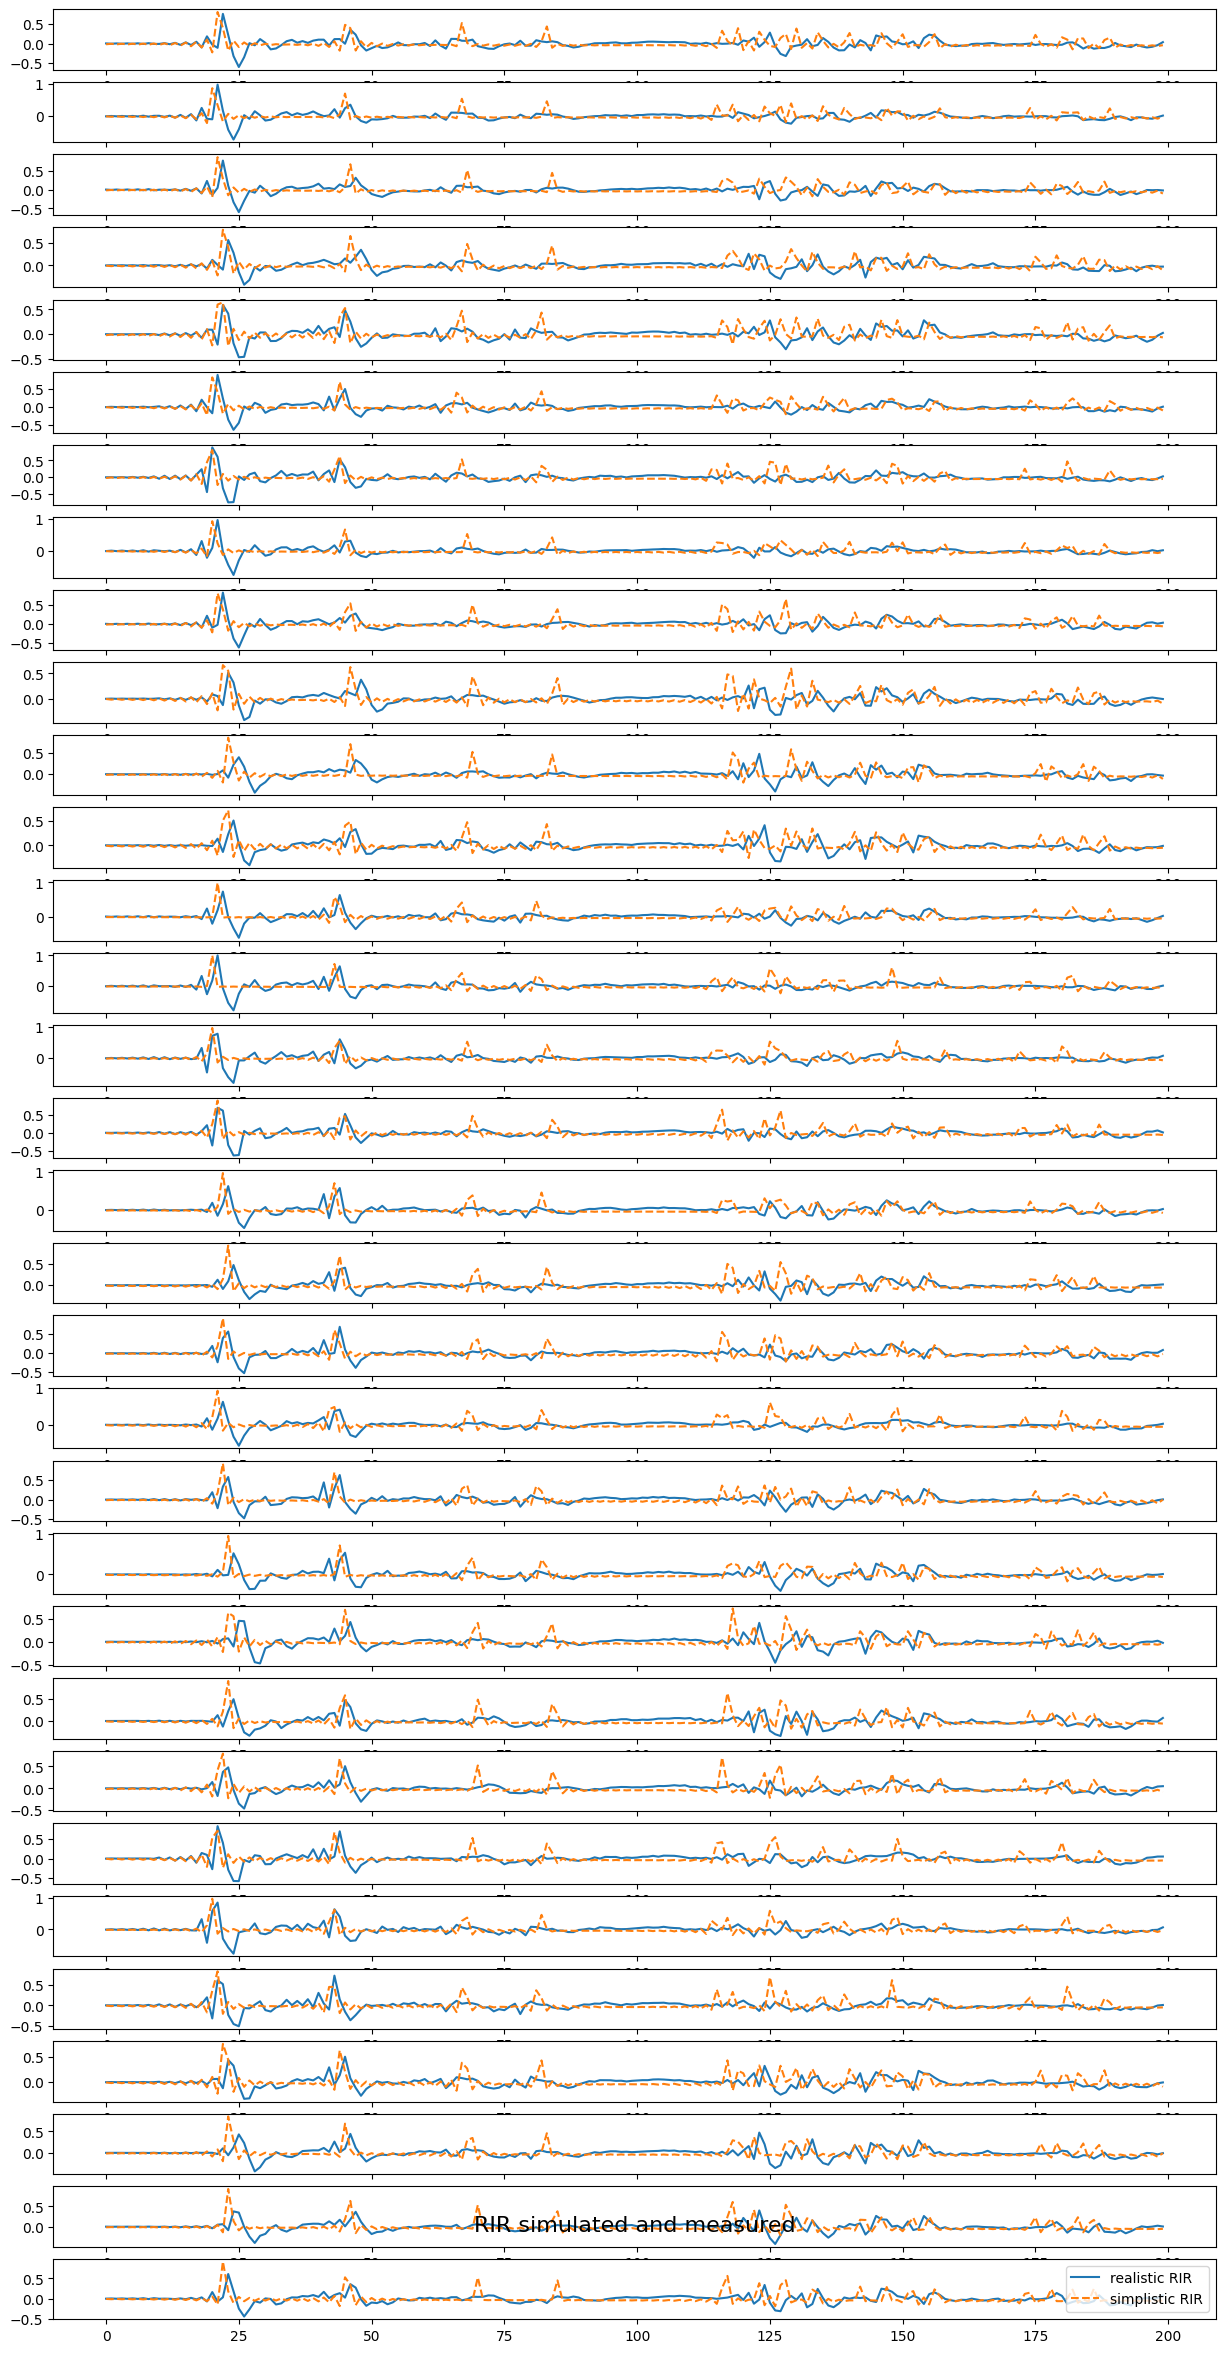

In [ ]:
fig, ax = plt.subplots(32,1,figsize=(15, 30), constrained_layout=True)
for i in range(32):
    ax[i].plot(room_data["real_rir"][i][:200], label="realistic RIR")
    ax[i].plot(room_data["perfect_rir"][i][:200], label="simplistic RIR", linestyle="--")
    ax[i].plot(room_data["measured_rir"][i][:200]/np.max(room_data["measured_rir"]), label="measured RIR", linestyle=":")
fig.suptitle("RIR simulated and measured", fontsize=16)
ax[0].legend()


# re-simulate with EM64

In [100]:
with np.load("C:/Users/jean-daniel.pascal/Documents/code_jd/pos_eigenmike64.npz") as data:
    pos_eigenmike = data['pos_Emic'] 

In [ ]:

fs = 16000
src_dir = MeasuredDirectivityFile("LSPs_HATS_GuitarCabinets_Akustikmessplatz", fs=fs,interp_order=18)
genelec8020 = src_dir.get_source_directivity("Genelec_8020", orientation=Rotation3D([ 0, 0], "yz", degrees=True))

df_annotation[df_annotation["room"] == 1].empty
df_annotation[df_annotation["room"] == 1]["src_xyz"].values[0]



abs_coeffs_lower_bound = np.array([[0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.05,0.15,0.25,0.30],
    [0.01,0.15,0.40,0.40,0.40,0.30]])

abs_coeffs_upper_bound = np.array([[0.50,0.50,0.30,0.12,0.12,0.12],
    [0.50,0.50,0.30,0.12,0.12,0.12],
    [0.50,0.50,0.30,0.12,0.12,0.12],
    [0.50,0.50,0.30,0.12,0.12,0.12],
    [0.20,0.30,0.50,0.60,0.75,0.80],
    [0.70,1.00,1.00,1.00,1.00,1.00]])

center_freqs = [125,250,500,1000,2000,4000,8000]




# --- Configuration du logger pour écrire dans un fichier ---
num_room = 1
positions_per_room = 1
distance_src_mics = 1
dist_mur = 1
max_order_ism = 20
delay = 81
limit = 1024 
crop_start = 85
count = 1


for room in range(1,num_room+1):
    print("room", room)
    # Dimensions of the room
    room_dim = df_annotation[df_annotation["room"] == room]["size_room"].values[0].tolist()

    # Generate #positions_per_room mesures in the room
    for pos in range(1, positions_per_room + 1 ):
        print("pos", pos)
        mask_orientation_source_f64 =  (
            (df_annotation["room"] == room)
            & (df_annotation["pos_num"] == pos)
            & (df_annotation["orientation"] == "front")
            & (df_annotation["orientation_value"] == 64)
            & (df_annotation["mic_id"] == 64))
        test_measurement = df_annotation[mask_orientation_source_f64]
        if test_measurement.empty : 
            print("empty for room and pos" , room, pos)
            continue

        pos_src, pos_mics = test_measurement["src_xyz"].values[0] , test_measurement["em64_xyz"].values[0]

        # Orientation
        # cartesian_coords = (pos_mics - pos_src ) 
        # r, theta, phi = fun.cartesian_to_spherical(cartesian_coords)
        angles_xyz_src = list(test_measurement["angle_xyz_src"].values[0])
        orientation = Rotation3D(angles_xyz_src, "xyz", degrees=True)

        # Orientation mic EM64
        angles_zyz = list(test_measurement["angle_zyz_em64"].values[0])
        orientation_mics = Rotation3D(angles_zyz, "zyz", degrees=True)
        

        # Pick random coefficient for absorption but realistic
        P = np.random.uniform(abs_coeffs_lower_bound,abs_coeffs_upper_bound)
        coin_flip = (np.random.rand(6,1) > 0.5)
        band_abs_profiles= coin_flip * P[np.random.randint(0,5,6),:]+(~coin_flip)*np.random.uniform(0.01,0.12,(6,6))
        band_abs_profiles = np.concatenate((band_abs_profiles,band_abs_profiles[:,-1].reshape(6,-1)),axis = 1)
        full_materials = pra.make_materials(
            ceiling={"description":'5',"coeffs" :((band_abs_profiles[5,:])).tolist(),"center_freqs" :center_freqs},
            floor={"description":'4',"coeffs" :(band_abs_profiles[4,:]).tolist(),"center_freqs" :center_freqs},
            east={"description":'1',"coeffs" :(band_abs_profiles[1,:]).tolist(),"center_freqs" :center_freqs},
            west={"description":'0',"coeffs" :(band_abs_profiles[0,:]).tolist(),"center_freqs" :center_freqs},
            north={"description":'3',"coeffs" :(band_abs_profiles[3,:]).tolist(),"center_freqs" :center_freqs},
            south={"description":'2',"coeffs" :(band_abs_profiles[2,:]).tolist(),"center_freqs" :center_freqs}
        )
        
        # Create the real room with real micro and source

        room_real = pra.ShoeBox(
            room_dim,
            fs=fs,
            max_order=max_order_ism,
            materials=full_materials,
            air_absorption=True,
            ray_tracing=False,
            min_phase=True,
        )

        # Add source and microphone 
        genelec8020 = src_dir.get_source_directivity(0, orientation=orientation)
        room_real.add_source(pos_src, directivity=genelec8020)   
        # Get the directivity objects from the files and add mics but here EM64 directivity pattern is unknown so we put omnidirectional mics
        list_dir = []
        # for j in range (32):
        #     dir_obj_Emic = eigenmike.get_mic_directivity(f"EM_32_{j}", orientation=orientation_mics)
        #     list_dir.append(dir_obj_Emic)
        # room_real.add_microphone_array(( np.zeros((32,3)) + pos_mics).T) # np.zeros((32,3)) pos_eigenmike.T

        # Create the "perfect" room with omnidirectional micro and source
        room_perfect = pra.ShoeBox(
            room_dim,
            fs=fs,
            max_order=max_order_ism,
            materials=full_materials,
            air_absorption=True,
            ray_tracing=False,
            min_phase=True,
        )

        # Add source and microphone omnidirectionnal
        room_perfect.add_source(pos_src)   
        list_pos = []
        for i in range(64):
            new_pos = orientation_mics.rotate(pos_eigenmike.T[i])
            list_pos.append(np.array(new_pos))
        room_perfect.add_microphone_array((list_pos + pos_mics).T) 
        room_real.add_microphone_array((list_pos + pos_mics).T) 
        # room_real.add_microphone_array(( list_pos + pos_mics).T , directivity=list_dir)  ## we don't have the directivity pattern of the em64

        # Compute the RIR
        room_real.compute_rir()
        room_perfect.compute_rir()
        rir_real = room_real.rir
        rir_perfect = room_perfect.rir
        
        # Reshape and transform as array instead of list of list
        max_perfect = np.max(np.array([(rir_perfect[i][0]).shape[0] for i in range(64)]))
        test_perfect = np.pad(np.array(rir_perfect[0][0]),(0,max_perfect-len(rir_perfect[0][0])),'constant',constant_values=[0,0])

        for i in range(1, 64):
            test_perfect = np.concatenate((test_perfect, np.pad(np.array(rir_perfect[i][0]), (0, max_perfect - len(rir_perfect[i][0])), 'constant', constant_values=[0, 0])))

        test_perfect = test_perfect.reshape(64, max_perfect)
        
        max_real = np.max(np.array([(rir_real[i][0]).shape[0] for i in range(64)]))
        test_real = np.pad(np.array(rir_real[0][0]), (0, max_real - len(rir_real[0][0])), 'constant', constant_values=[0, 0])

        for i in range(1, 64):
            test_real = np.concatenate((test_real, np.pad(np.array(rir_real[i][0]), (0, max_real - len(rir_real[i][0])), 'constant', constant_values=[0, 0])))

        test_real = test_real.reshape(64, max_real)

        # Normalize the RIR and put in the dictionnary
        test_real = test_real[ : , crop_start + delay : crop_start + limit + delay] / np.max(test_real[ : , crop_start + delay : crop_start + limit + delay]).reshape(-1,1)
        test_perfect = test_perfect[ : , crop_start : crop_start + limit ] / np.max(test_perfect[ : , crop_start : crop_start + limit ]).reshape(-1,1)


        ##  Annotation of the image sources

        for s, src in enumerate(room_perfect.sources):
            order = src.orders
            src_image = (src.images)
            list_src = []
            list_ordre = []
            for i in range(src_image.shape[1]):
                if np.linalg.norm(src_image[: , i] - pos_mics) < 15:
                    list_src.append(src_image[:, i] - pos_mics)
                    list_ordre.append(order[i])

            list_src = np.array(list_src)
            list_ordre = np.array(list_ordre)
            # simplifiée puis algo de tom
            idx_sorted = np.argsort(np.linalg.norm(list_src,axis=1))
            x_sorted = list_src[idx_sorted]
            list_src = x_sorted
            x_sorted_ord = list_ordre[idx_sorted]
            list_ordre = x_sorted_ord

        path = test_measurement["path"].values[0]
        with sf.SoundFile(path) as f:
            x, fsx = sf.read(path)
            test = x.T
        
        # Resampling parameters
        fs_in = fsx
        fs_out = fs
        down_factor = fs_in // fs_out  # here is 3

        # Downsampling per channel
        audio_downsampled = resample_poly(test, up=1, down=down_factor, axis=1)

        
      
        room_data = {
            "real_rir": test_real.tolist(),
            "measured_rir": audio_downsampled[:,95: 95 + limit].tolist(),
            "perfect_rir": test_perfect.tolist(),
            "max_order_ism": max_order_ism,
            "geometry": {
                "room_dim": room_dim,
                "pos_src": pos_src.tolist(),
                "pos_mics": pos_mics.tolist(),
                "name": [room, pos]
            },
            "abs_coeffs": band_abs_profiles.tolist(),
            'ground_truth' : list_src.tolist(),
            'order' : list_ordre.tolist(),
            }
        output_file_path = f"./dataset_measurement_cerema/room_0_{count}.json.gz"
        with gzip.open(output_file_path, "wt", encoding="utf-8") as f:
            json.dump(room_data, f)
        count += 1



room 1
pos 6


Text(0.5, 1.0, 'RIR simulée avec directivités')

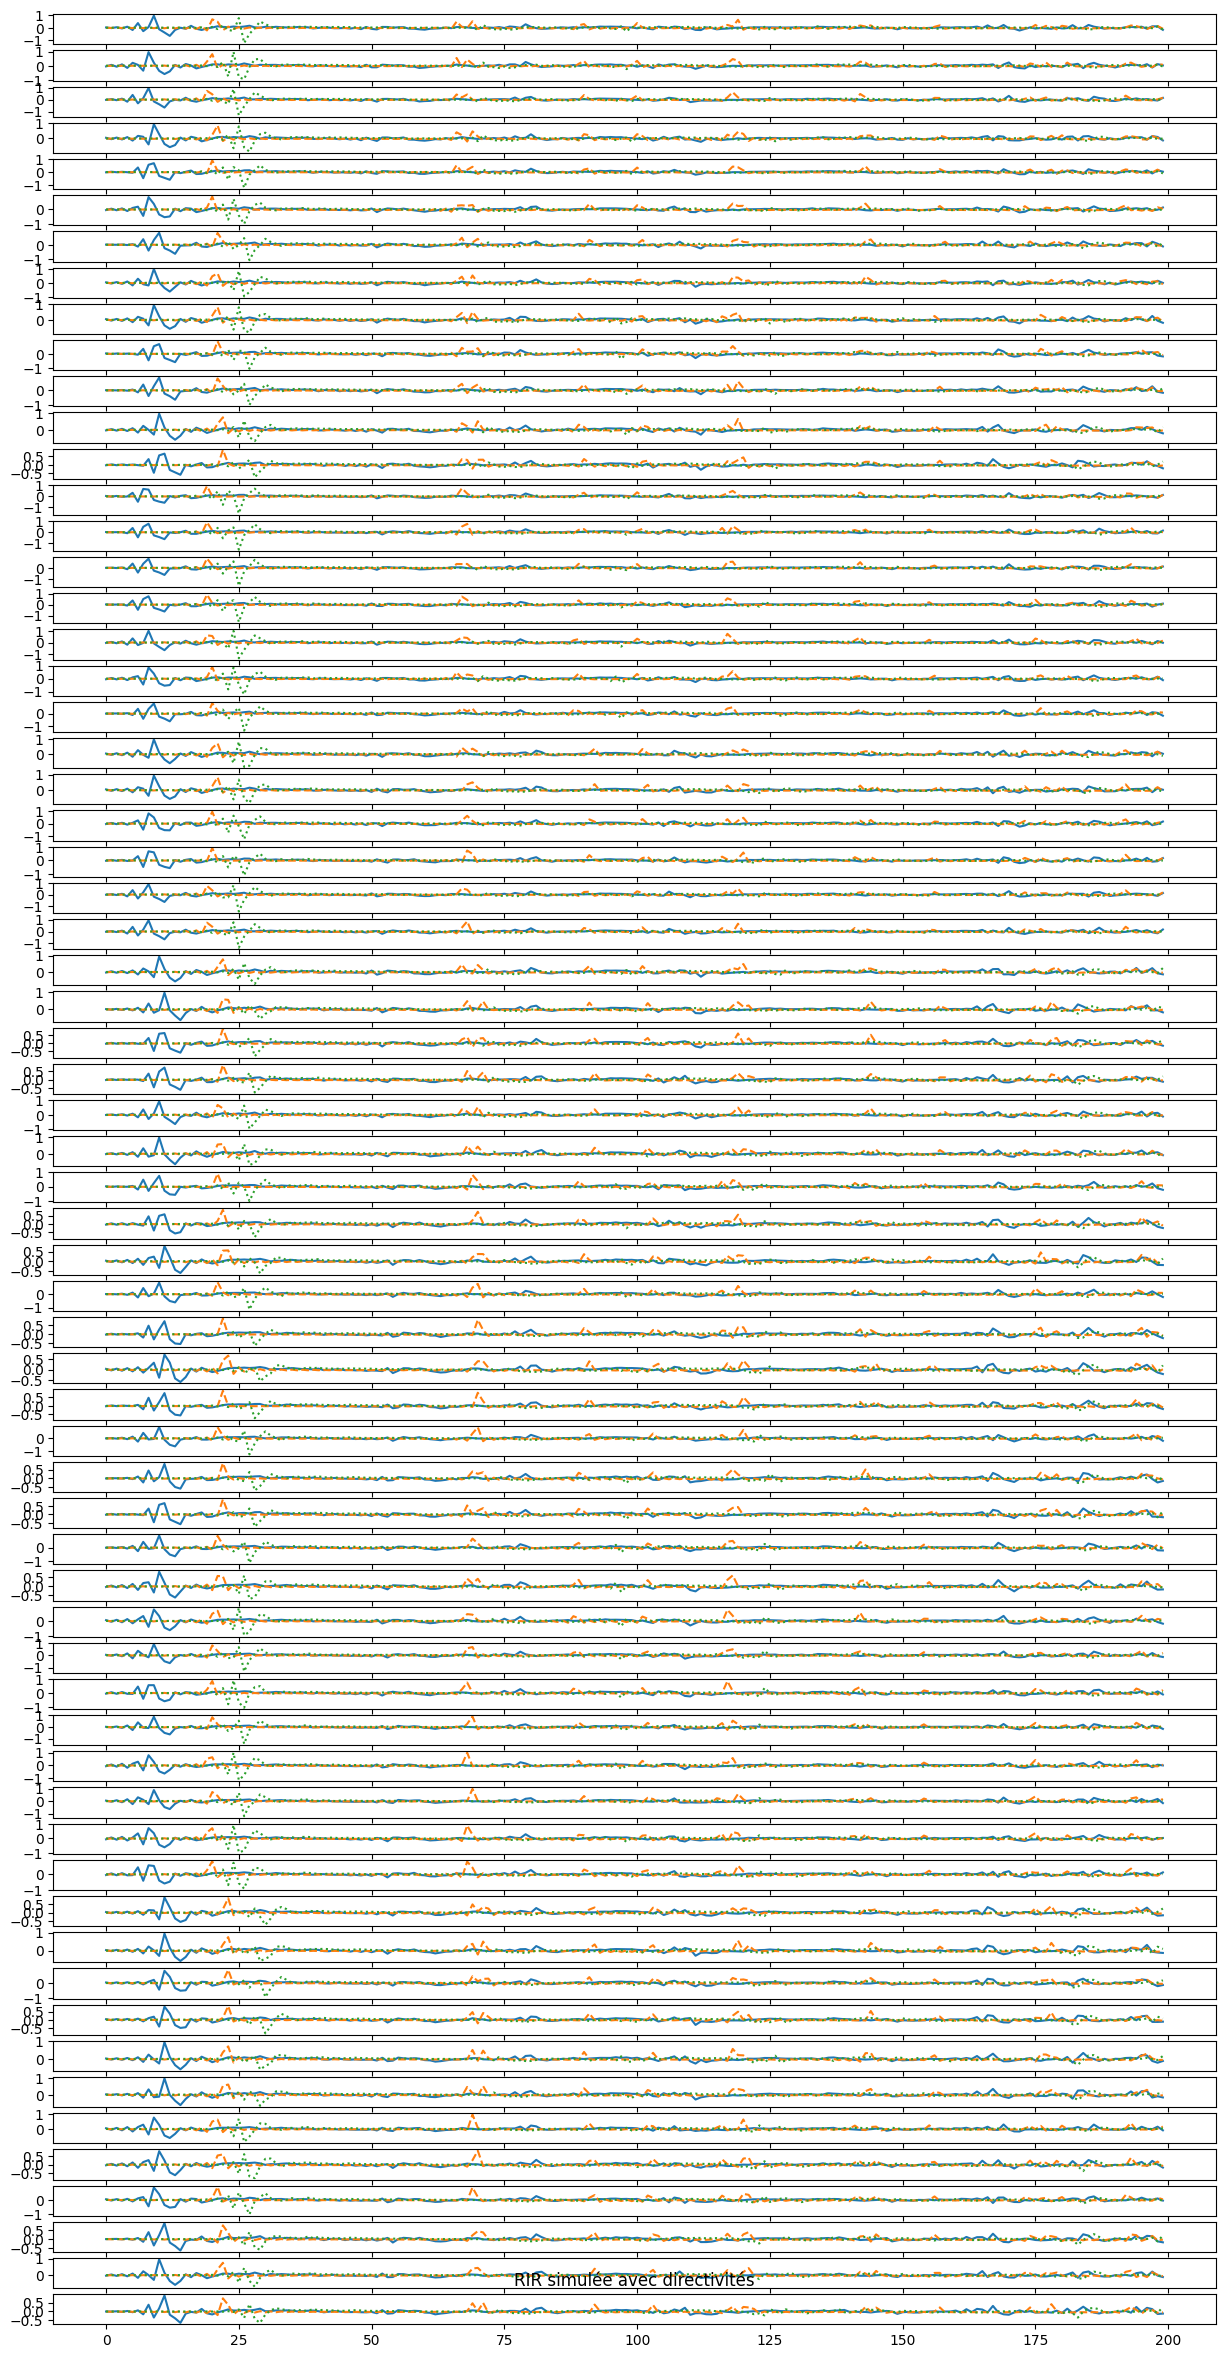

In [ ]:
fig, ax = plt.subplots(64,1,figsize=(15, 30), constrained_layout=True)
for i in range(64):
    ax[i].plot(room_data["real_rir"][i][:200], label="realistic RIR")
    ax[i].plot(room_data["perfect_rir"][i][:200], label="simplistic RIR", linestyle="--")
    ax[i].plot(room_data["measured_rir"][i][:200]/np.max(room_data["measured_rir"]), label="measured RIR", linestyle=":")
fig.suptitle("RIR simulated and measured", fontsize=16)
ax[0].legend()